## Unemployment in India \u2013 simple analysis

This notebook does a quick and simple look at unemployment data for India using Python. We load the CSV file, clean it a bit, make a few plots and check what happened around Covid-19.

In [1]:
# imports and loading data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# read the csv file (in the same folder as this notebook)
file_path = "Unemployment in India.csv"
df = pd.read_csv(file_path, skipinitialspace=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [2]:
# quick overview of the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isna().sum())

# drop duplicate rows if there are any
df = df.drop_duplicates().copy()

# convert Date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')

# make shorter column names for easier typing
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_participation'
})

df.head()

Shape: (768, 7)

Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Missing values per column:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


,Region,Date,Frequency,Unemployment_rate,Employed,Labour_participation,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
290,Telangana,2019-05-31,Monthly,2.23,11053353.0,61.74,Rural
276,Tamil Nadu,2019-05-31,Monthly,0.97,15844698.0,49.44,Rural
257,Rajasthan,2019-05-31,Monthly,4.03,15226005.0,38.52,Rural
243,Punjab,2019-05-31,Monthly,9.17,6088547.0,44.79,Rural


### Overall unemployment trend

Let's first see how the average unemployment rate changes over time for the whole country (just a simple mean across all regions).

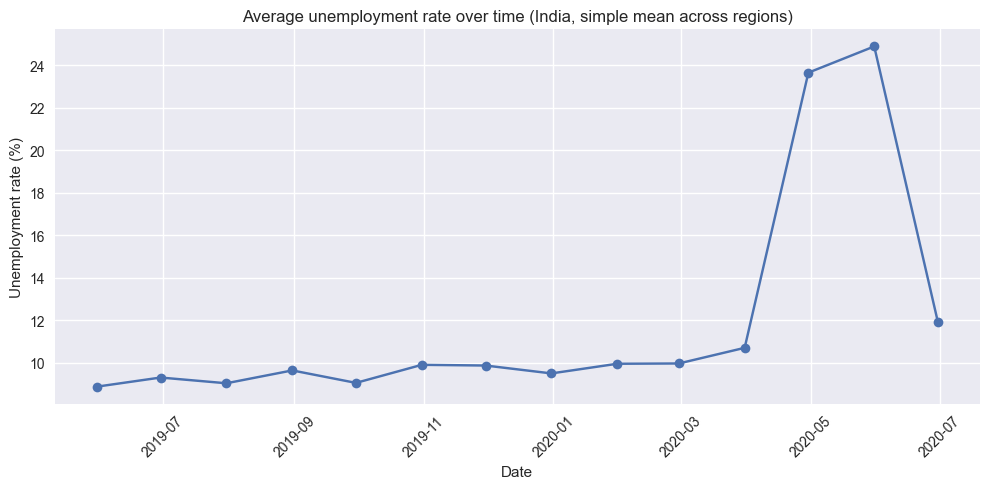

In [3]:
# average unemployment rate over time (all regions combined)
monthly = df.groupby('Date')['Unemployment_rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly['Date'], monthly['Unemployment_rate'], marker='o')
plt.title('Average unemployment rate over time (India, simple mean across regions)')
plt.xlabel('Date')
plt.ylabel('Unemployment rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Covid-19 impact on unemployment

Now we mark the start of Covid-19 (around March 2020) and compare average unemployment before and after that point.

Pre-Covid period: 2019-05-31 to 2020-02-29
Covid period: 2020-03-31 to 2020-06-30

Average unemployment rate before Covid: 9.51 %
Average unemployment rate during Covid period: 17.78 %


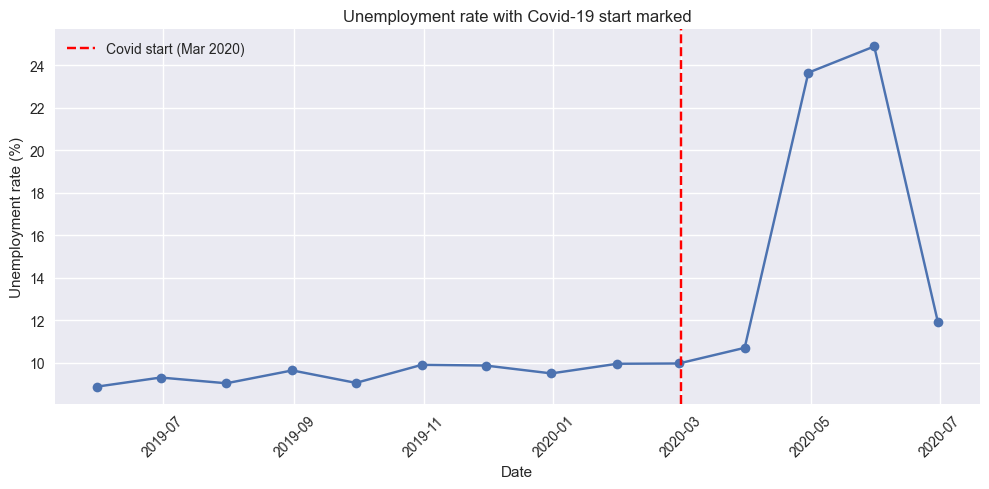

In [4]:
# comparing pre-Covid and Covid period unemployment
covid_start = pd.Timestamp('2020-03-01')

pre_covid = monthly[monthly['Date'] < covid_start]
covid_period = monthly[monthly['Date'] >= covid_start]

print("Pre-Covid period:", pre_covid['Date'].min().date(), "to", pre_covid['Date'].max().date())
print("Covid period:", covid_period['Date'].min().date(), "to", covid_period['Date'].max().date())

print("\nAverage unemployment rate before Covid:", round(pre_covid['Unemployment_rate'].mean(), 2), '%')
print("Average unemployment rate during Covid period:", round(covid_period['Unemployment_rate'].mean(), 2), '%')

plt.figure(figsize=(10, 5))
plt.plot(monthly['Date'], monthly['Unemployment_rate'], marker='o')
plt.axvline(covid_start, color='red', linestyle='--', label='Covid start (Mar 2020)')
plt.title('Unemployment rate with Covid-19 start marked')
plt.xlabel('Date')
plt.ylabel('Unemployment rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Simple seasonal pattern (by month)

We can also look at how the unemployment rate behaves in different months of the year.

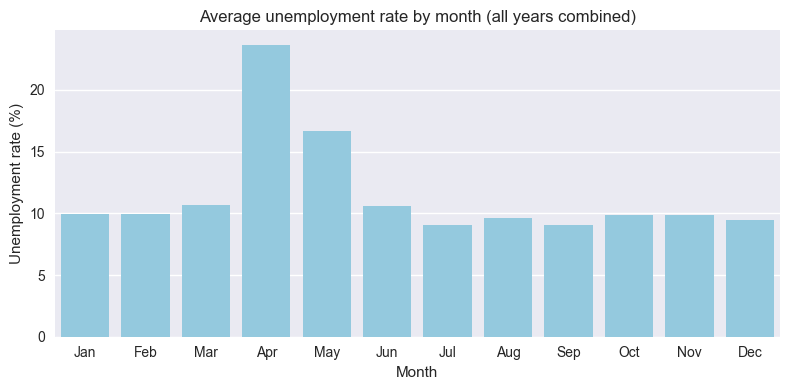

In [5]:
# average unemployment rate by month of the year
df['month'] = df['Date'].dt.month_name().str[:3]
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_avg = df.groupby('month')['Unemployment_rate'].mean().reindex(month_order)

plt.figure(figsize=(8, 4))
sns.barplot(x=month_avg.index, y=month_avg.values, color='skyblue')
plt.title('Average unemployment rate by month (all years combined)')
plt.xlabel('Month')
plt.ylabel('Unemployment rate (%)')
plt.tight_layout()
plt.show()

### Simple takeaways

Based on the plots above you should see things like:

- Unemployment in 2019 is lower and more stable compared to the big spike around the first Covid lockdown months (around April\u2013May 2020).
- After the first Covid wave, unemployment comes down again but stays a bit more jumpy than before.
- Some states/regions have much higher unemployment than others; you can also group the data by `Region` and repeat the same kind of plots for a deeper look.

This is just a simple project: you can add more graphs, focus on one state, or compare rural vs urban areas if you want to extend it.